<a href="https://colab.research.google.com/github/tanviupadhyay1517/Hypothesis-Testing-/blob/main/Indep_t_test_employee_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study
A mid-sized organization recently hired two different HR consultants—Consultant A and Consultant B—to conduct training programs for its employees. After the sessions, employees were evaluated on various performance metrics, and a composite score out of 100 was assigned to each employee based on knowledge retention, engagement, and post-training performance.
Can we conclude that Consultant A leads to significantly lesser employee performance scores compared to Consultant B? [Data:employee_score.xlsx]

# Import necessary packages

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Mounting Google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Read data

In [3]:
# Reading the data

es = pd.read_excel('/content/drive/MyDrive/Classroom/FTN Batch 10/T test Two sample/employee_score.xlsx')

# Exploratory Analysis

In [10]:
es.columns

Index(['Consultant', 'Score'], dtype='object')

In [4]:
es.head()                                   # Viewing first few observations of the data

,Consultant,Score
0,Consultant_A,17
1,Consultant_A,18
2,Consultant_A,21
3,Consultant_A,22
4,Consultant_A,25


In [5]:
es.describe()                               # Descriptive statistics

,Score
count,20.000000
mean,20.600000
std,2.280351
min,17.000000
25%,18.750000
50%,21.000000
75%,22.000000
max,25.000000


<Axes: title={'center': 'Score'}, xlabel='Consultant'>

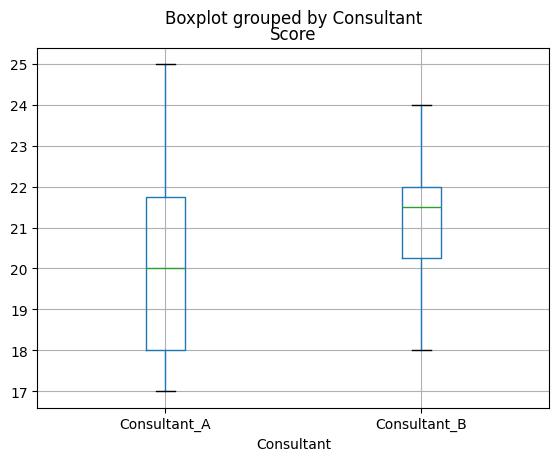

In [11]:
es.boxplot(by ='Consultant', column =['Score'])  # Box-plot

# Normality test using Shapiro test

In [20]:
Shapiro1 = stats.shapiro(es.loc[es['Consultant'] == 'Consultant_A', 'Score'])
print("Shapiro-Wilk test for Counsultant A:", Shapiro1)

Shapiro-Wilk test for Counsultant A: ShapiroResult(statistic=np.float64(0.9170861313185181), pvalue=np.float64(0.3332916791313667))


In [21]:
Shapiro2 = stats.shapiro(es.loc[es['Consultant'] == 'Consultant_B', 'Score'])
print("Shapiro-Wilk test for Consultant_B:", Shapiro2)

Shapiro-Wilk test for Consultant_B: ShapiroResult(statistic=np.float64(0.9668844627926777), pvalue=np.float64(0.8605521188131243))


# Normality check using Q-Q plot

In [14]:
from statsmodels.graphics.gofplots import qqplot
from matplotlib import pyplot

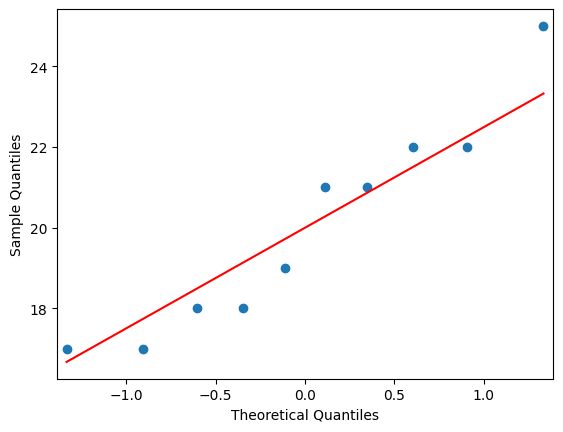

In [15]:
qqplot(es.loc[es['Consultant'] == 'Consultant_A', 'Score'], line='s')
plt.show()

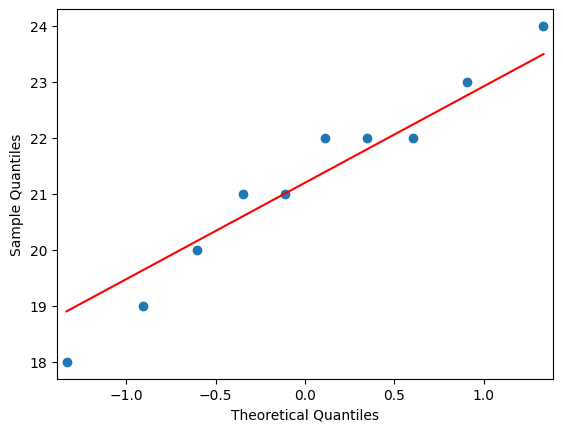

In [16]:
qqplot(es.loc[es['Consultant'] == 'Consultant_B', 'Score'], line='s')
plt.show()


## Testing Equality of Variances

In [17]:
# Levene test using Center as Mean
stats.levene(
    es.loc[es['Consultant'] == 'Consultant_A', 'Score'],
    es.loc[es['Consultant'] == 'Consultant_B', 'Score'],
    center='mean'
)

LeveneResult(statistic=np.float64(2.440677966101697), pvalue=np.float64(0.13563498357299628))

# Independent t test

In [22]:
res = stats.ttest_ind(
    es.loc[es['Consultant'] == 'Consultant_A', 'Score'],
    es.loc[es['Consultant'] == 'Consultant_B', 'Score'],
    equal_var=True,
    alternative='less'
)
res

TtestResult(statistic=np.float64(-1.189473480819161), pvalue=np.float64(0.12485383500779697), df=np.float64(18.0))

In [19]:
print("Average performance of Consultant A employees:", es.loc[es['Consultant'] == 'Consultant_A', 'Score'].mean())
print("Average performance of Consultant B employees :",es.loc[es['Consultant'] == 'Consultant_B', 'Score'].mean())

Average performance of Consultant A employees: 20.0
Average performance of Consultant B employees : 21.2
